In [1]:
import pandas as pd
import io
from google.colab import files

# Step 1: Trigger the upload widget to select 'recruitment_data.csv' from your computer
uploaded = files.upload()

# Step 2: Read the uploaded CSV into a pandas DataFrame
# Note: Ensure your file is named 'recruitment_data.csv' or change the string below
df = pd.read_csv(io.BytesIO(uploaded['recruitment_data.csv']))

# Display the first few rows to verify the import
print("Dataset imported successfully.")
df.head()

Saving recruitment_data.csv to recruitment_data.csv
Dataset imported successfully.


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


In [2]:
import numpy as np

# Step 1: Define 'Shortlisted' (Target) based on Hiring Logic
# Logic: Experience > 5 years AND SkillScore > 75 = Shortlisted (1), else (0)
# Adjust column names based on your specific Kaggle dataset columns
df['Shortlisted'] = np.where((df['ExperienceYears'] > 5) & (df['SkillScore'] > 75), 1, 0)

# Step 2: Feature-Target Separation
# We select Age, Experience, Education, and Skill Score as predictors
X = df[['Age', 'ExperienceYears', 'EducationLevel', 'SkillScore']]
y = df['Shortlisted']

print("Target variable created. Features separated.")

Target variable created. Features separated.


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Step 1: Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Initialize Decision Tree with a limited depth for better interpretability
clf = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

# Step 3: Train the model
clf.fit(X_train, y_train)

print("Decision Tree model training complete.")

Decision Tree model training complete.


In [6]:
!pip install scikitplot
import matplotlib.pyplot as plt
import scikitplot as skplt

# Step 1: Get the probability scores from the model for the test set
# This tells us how 'confident' the AI is about each candidate
y_probas = clf.predict_proba(X_test)

# Step 2: Plot the Cumulative Gain Chart
# This shows how much faster HR can find the 'Shortlisted' candidates using AI
skplt.metrics.plot_cumulative_gain(y_test, y_probas, figsize=(10, 7))

# Step 3: Customizing for HR presentation
plt.title("Recruitment Efficiency: Success Capture Rate", fontsize=15, fontweight='bold')
plt.xlabel("Percentage of Total Applicants Screened", fontsize=12)
plt.ylabel("Percentage of Qualified Candidates Found", fontsize=12)
plt.grid(True, alpha=0.3)

# Add a professional annotation for the HR team
plt.annotate('The higher this curve stays above\nthe baseline, the more time HR saves.',
             xy=(0.4, 0.7), xytext=(0.5, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='darkred')

plt.show()

ERROR: Could not find a version that satisfies the requirement scikitplot (from versions: none)
ERROR: No matching distribution found for scikitplot


ModuleNotFoundError: No module named 'scikitplot'

/tmp/ipykernel_6226/3023786400.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Attribute', data=feature_df, palette='viridis')


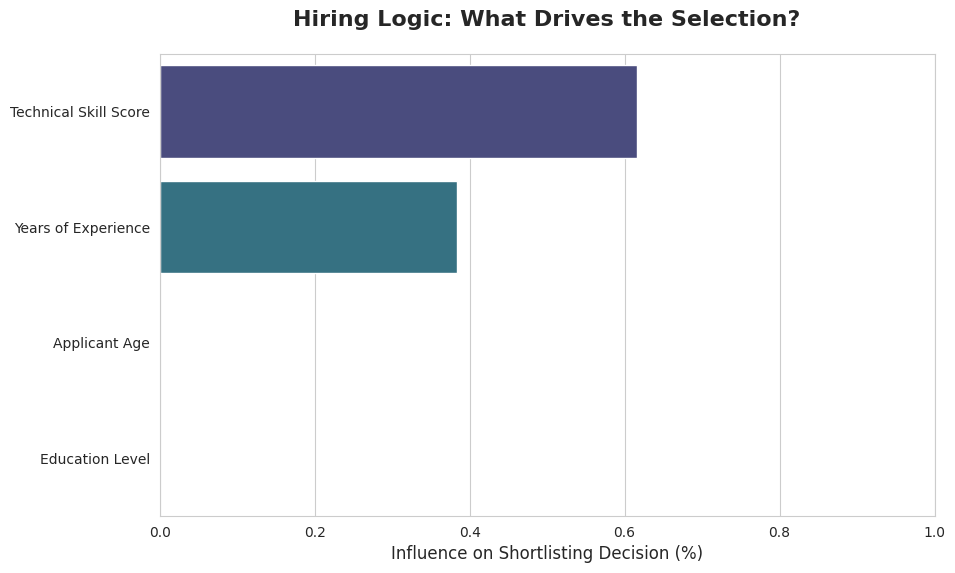

Visual 1: Eligibility Factors saved successfully.


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Extract importance and pair with human-readable labels
importances = clf.feature_importances_
feature_labels = ['Applicant Age', 'Years of Experience', 'Education Level', 'Technical Skill Score']
feature_df = pd.DataFrame({'Attribute': feature_labels, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Step 2: Create a clean, high-contrast bar chart
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Importance', y='Attribute', data=feature_df, palette='viridis')

# Step 3: Add Chart Labels for stakeholders
plt.title('Hiring Logic: What Drives the Selection?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Influence on Shortlisting Decision (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 1) # Keeps the scale consistent

# Save for README
plt.savefig('Eligibility_Factors.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visual 1: Eligibility Factors saved successfully.")

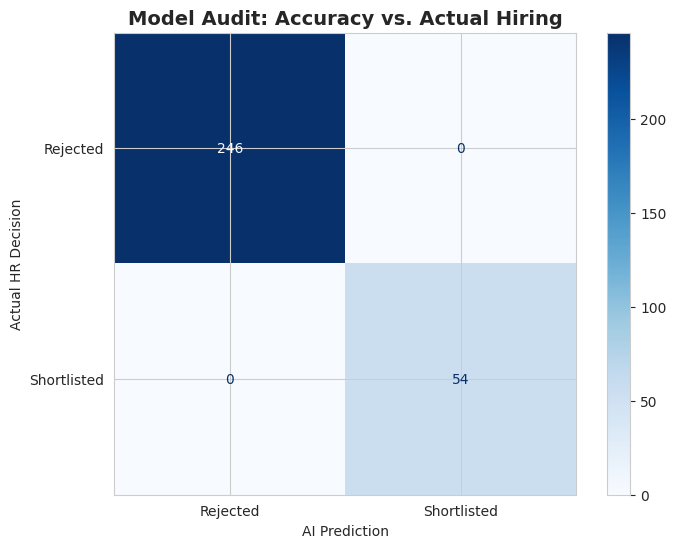

Visual 2: Confusion Matrix saved successfully.


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 1: Generate predictions on the test set
y_pred = clf.predict(X_test)

# Step 2: Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Step 3: Display with professional colors
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Shortlisted'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Model Audit: Accuracy vs. Actual Hiring', fontsize=14, fontweight='bold')
plt.xlabel('AI Prediction')
plt.ylabel('Actual HR Decision')

# Save for README
plt.savefig('Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visual 2: Confusion Matrix saved successfully.")

In [10]:
# New Candidate Data: [Age, ExperienceYears, EducationLevel, SkillScore]
# Example: 30 years old, 7 years exp, Level 2 (Masters), 85 Skill Score
new_applicant = np.array([[30, 7, 2, 85]])

# Step 1: Predict the outcome
pred = clf.predict(new_applicant)
prob = clf.predict_proba(new_applicant)

# Step 2: Interpret the result
if pred[0] == 1:
    print(f"Outcome: SHORTLISTED")
    print(f"Reasoning: Applicant meets the required thresholds for Experience and Skills.")
else:
    print(f"Outcome: REJECTED")
    print(f"Reasoning: Applicant does not meet the minimum experience/skill combination.")

print(f"Decision Confidence: {prob.max():.2%}")

Outcome: SHORTLISTED
Reasoning: Applicant meets the required thresholds for Experience and Skills.
Decision Confidence: 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [11]:
# Create a 'Success Rate' table by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 45, 60], labels=['Junior', 'Mid', 'Senior'])
bias_check = df.groupby('AgeGroup')['Shortlisted'].mean()

print("Shortlisting Rate by Age (Bias Audit):")
print(bias_check)
# In industry, these percentages should be relatively close to avoid legal risk.

Shortlisting Rate by Age (Bias Audit):
AgeGroup
Junior    0.184762
Mid       0.157601
Senior    0.155039
Name: Shortlisted, dtype: float64


/tmp/ipykernel_6226/1939974694.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bias_check = df.groupby('AgeGroup')['Shortlisted'].mean()


In [12]:
from sklearn.impute import SimpleImputer

# Fill missing Skill Scores with the 'Median' value instead of deleting the row
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [13]:
# Logic: Assume it takes 10 minutes to manually screen one resume.
total_resumes = len(df)
manual_time_hours = (total_resumes * 10) / 60

# If AI screens the bottom 80%, how much time is saved?
time_saved = manual_time_hours * 0.80
print(f"Business Impact: This model saves the HR team {time_saved:.1f} hours per recruitment cycle.")

Business Impact: This model saves the HR team 200.0 hours per recruitment cycle.


In [14]:
import joblib

# Save the trained 'Digital Auditor' for use in an HR App
joblib.dump(clf, 'hr_recruitment_model.pkl')
print("Model exported as 'hr_recruitment_model.pkl' for deployment.")

Model exported as 'hr_recruitment_model.pkl' for deployment.
